## Week 3: Forward Selection, Backward Selection, PCR, and PLSR

This notebook applies Week 3 concepts from DX799 Capstone Part 1 
to the BRFSS 2015 diabetes dataset. Building on Weeks 1 and 2, 
this week explores feature selection through forward and backward 
selection, and dimensionality reduction through Principal Component 
Regression (PCR) and Partial Least Squares Regression (PLSR).

Dataset: diabetes_binary_5050split_health_indicators_BRFSS2015.csv
Target variable: Diabetes_binary (0 = no diabetes, 1 = diabetes)

In [2]:
# DX799 Capstone Part 1 - Week 3
# Forward/Backward Selection, PCR, and PLSR

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.metrics import r2_score
from sklearn.cross_decomposition import PLSRegression

## Load and Prepare Data

Loading the same balanced 50/50 BRFSS dataset used in Weeks 1 and 2.
Splitting into train and test sets and scaling features since PCR 
and PLSR are sensitive to feature scale.

In [3]:
# Load dataset
df = pd.read_csv("diabetes_binary_5050split_health_indicators_BRFSS2015.csv")

# Define features and target
target = 'Diabetes_binary'
feature_cols = [col for col in df.columns if col != target]
X = df[feature_cols]
y = df[target]

# Train test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Scale features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Train size:", X_train_scaled.shape)
print("Test size:", X_test_scaled.shape)
print("Features:", feature_cols)

Train size: (56553, 21)
Test size: (14139, 21)
Features: ['HighBP', 'HighChol', 'CholCheck', 'BMI', 'Smoker', 'Stroke', 'HeartDiseaseorAttack', 'PhysActivity', 'Fruits', 'Veggies', 'HvyAlcoholConsump', 'AnyHealthcare', 'NoDocbcCost', 'GenHlth', 'MentHlth', 'PhysHlth', 'DiffWalk', 'Sex', 'Age', 'Education', 'Income']


## Forward Selection

Forward selection starts with no features and adds one at a time, 
keeping whichever feature improves the model most at each step. 
This is a greedy method meaning it commits to each choice and never 
reconsiders. Stopping criterion: continue until adding more features 
stops improving R-squared on the test set.

In [4]:
# Forward Selection
remaining_features = list(feature_cols)
selected_features = []
best_r2 = 0
r2_history = []

while remaining_features:
    best_feature = None
    for feature in remaining_features:
        candidate = selected_features + [feature]
        model = LinearRegression()
        model.fit(X_train[candidate], y_train)
        r2 = r2_score(y_test, model.predict(X_test[candidate]))
        if r2 > best_r2:
            best_r2 = r2
            best_feature = feature

    if best_feature is None:
        break

    selected_features.append(best_feature)
    remaining_features.remove(best_feature)
    r2_history.append(best_r2)
    print(f"Added: {best_feature:<25} | Features: {len(selected_features):>2} | R²: {best_r2:.4f}")

print(f"\nFinal selected features ({len(selected_features)}):")
print(selected_features)

Added: GenHlth                   | Features:  1 | R²: 0.1576
Added: HighBP                    | Features:  2 | R²: 0.2321
Added: Age                       | Features:  3 | R²: 0.2547
Added: BMI                       | Features:  4 | R²: 0.2834
Added: HighChol                  | Features:  5 | R²: 0.2939
Added: HvyAlcoholConsump         | Features:  6 | R²: 0.2969
Added: Income                    | Features:  7 | R²: 0.2994
Added: CholCheck                 | Features:  8 | R²: 0.3021
Added: Sex                       | Features:  9 | R²: 0.3045
Added: HeartDiseaseorAttack      | Features: 10 | R²: 0.3052
Added: PhysHlth                  | Features: 11 | R²: 0.3058
Added: DiffWalk                  | Features: 12 | R²: 0.3064
Added: Education                 | Features: 13 | R²: 0.3068
Added: Veggies                   | Features: 14 | R²: 0.3070
Added: MentHlth                  | Features: 15 | R²: 0.3073
Added: Fruits                    | Features: 16 | R²: 0.3074
Added: AnyHealthcare    

## Backward Selection

Backward selection starts with all 21 features and removes the 
least useful one at a time. Comparing final selected features 
to forward selection to see whether both methods agree on which 
features to keep.

In [5]:
# Backward Selection
remaining_features = list(feature_cols)
r2_history_back = []

# Start with all features
model = LinearRegression()
model.fit(X_train[remaining_features], y_train)
current_r2 = r2_score(y_test, model.predict(X_test[remaining_features]))
print(f"Starting R² with all features: {current_r2:.4f}")

while len(remaining_features) > 1:
    worst_feature = None
    best_r2_after_removal = -np.inf

    for feature in remaining_features:
        candidate = [f for f in remaining_features if f != feature]
        model = LinearRegression()
        model.fit(X_train[candidate], y_train)
        r2 = r2_score(y_test, model.predict(X_test[candidate]))
        if r2 > best_r2_after_removal:
            best_r2_after_removal = r2
            worst_feature = feature

    if best_r2_after_removal < current_r2 - 0.001:
        break

    remaining_features.remove(worst_feature)
    current_r2 = best_r2_after_removal
    r2_history_back.append(current_r2)
    print(f"Removed: {worst_feature:<25} | Features left: {len(remaining_features):>2} | R²: {current_r2:.4f}")

print(f"\nFinal selected features ({len(remaining_features)}):")
print(remaining_features)

Starting R² with all features: 0.3073
Removed: PhysActivity              | Features left: 20 | R²: 0.3074
Removed: Stroke                    | Features left: 19 | R²: 0.3074
Removed: Smoker                    | Features left: 18 | R²: 0.3074
Removed: NoDocbcCost               | Features left: 17 | R²: 0.3074
Removed: AnyHealthcare             | Features left: 16 | R²: 0.3074
Removed: Fruits                    | Features left: 15 | R²: 0.3073
Removed: MentHlth                  | Features left: 14 | R²: 0.3070
Removed: Veggies                   | Features left: 13 | R²: 0.3068
Removed: Education                 | Features left: 12 | R²: 0.3064
Removed: DiffWalk                  | Features left: 11 | R²: 0.3058
Removed: PhysHlth                  | Features left: 10 | R²: 0.3052
Removed: HeartDiseaseorAttack      | Features left:  9 | R²: 0.3045

Final selected features (9):
['HighBP', 'HighChol', 'CholCheck', 'BMI', 'HvyAlcoholConsump', 'GenHlth', 'Sex', 'Age', 'Income']


## Comparison: Forward vs Backward Selection

Comparing which features each method selected to see where 
they agree and where they differ.

In [6]:
# Compare forward and backward selection results
forward_set = set(selected_features)
backward_set = set(remaining_features)

agreed = forward_set.intersection(backward_set)
only_forward = forward_set - backward_set
only_backward = backward_set - forward_set

print("Features selected by BOTH methods:")
for f in sorted(agreed):
    print(f"  {f}")

print(f"\nFeatures selected by Forward ONLY:")
for f in sorted(only_forward):
    print(f"  {f}")

print(f"\nFeatures selected by Backward ONLY:")
for f in sorted(only_backward):
    print(f"  {f}")

print(f"\nForward R²:  {r2_history[-1]:.4f} ({len(selected_features)} features)")
print(f"Backward R²: {current_r2:.4f} ({len(remaining_features)} features)")

Features selected by BOTH methods:
  Age
  BMI
  CholCheck
  GenHlth
  HighBP
  HighChol
  HvyAlcoholConsump
  Income
  Sex

Features selected by Forward ONLY:
  AnyHealthcare
  DiffWalk
  Education
  Fruits
  HeartDiseaseorAttack
  MentHlth
  PhysHlth
  Veggies

Features selected by Backward ONLY:

Forward R²:  0.3074 (17 features)
Backward R²: 0.3045 (9 features)


## Principal Component Regression (PCR)

PCR transforms features into uncorrelated principal components 
using PCA, then runs linear regression on those components. 
This eliminates multicollinearity by design. Testing different 
numbers of components to find the optimal balance between 
complexity and performance. In Week 11 of Module B, 17 components 
were needed to explain 90% of variance in this dataset.

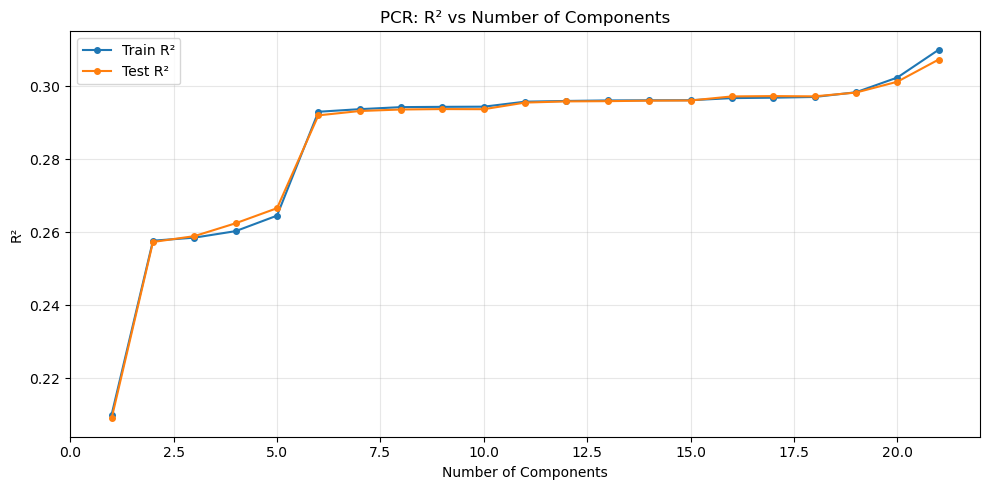

Best number of components: 21
Best PCR Test R²: 0.3073
PCR Train R² at best: 0.3100


In [7]:
# PCR - test different numbers of components
n_components_range = range(1, 22)
pcr_train_r2 = []
pcr_test_r2 = []

for n in n_components_range:
    pca = PCA(n_components=n)
    X_train_pca = pca.fit_transform(X_train_scaled)
    X_test_pca = pca.transform(X_test_scaled)
    
    model = LinearRegression()
    model.fit(X_train_pca, y_train)
    
    pcr_train_r2.append(r2_score(y_train, model.predict(X_train_pca)))
    pcr_test_r2.append(r2_score(y_test, model.predict(X_test_pca)))

# Plot results
plt.figure(figsize=(10, 5))
plt.plot(n_components_range, pcr_train_r2, label='Train R²', marker='o', markersize=4)
plt.plot(n_components_range, pcr_test_r2, label='Test R²', marker='o', markersize=4)
plt.xlabel('Number of Components')
plt.ylabel('R²')
plt.title('PCR: R² vs Number of Components')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

best_n = np.argmax(pcr_test_r2) + 1
print(f"Best number of components: {best_n}")
print(f"Best PCR Test R²: {pcr_test_r2[best_n-1]:.4f}")
print(f"PCR Train R² at best: {pcr_train_r2[best_n-1]:.4f}")

## Partial Least Squares Regression (PLSR)

PLSR selects components that maximize covariance between features 
and the target variable Y, unlike PCR which only considers variance 
in X. Testing different numbers of components to compare against 
PCR results. Expecting PLSR to reach similar or better R-squared 
with fewer components since each component is chosen with the 
target in mind.

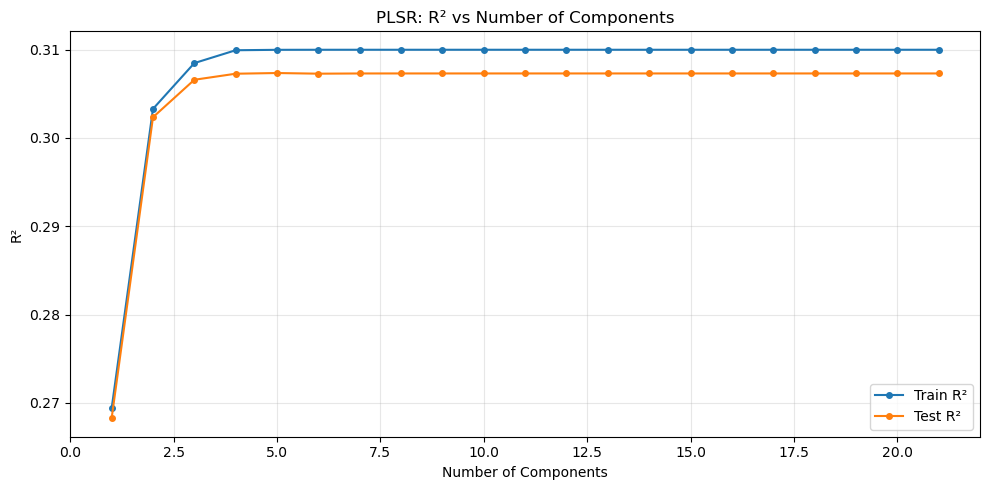

Best number of components: 5
Best PLSR Test R²: 0.3073
PLSR Train R² at best: 0.3100


In [8]:
# PLSR - test different numbers of components
plsr_train_r2 = []
plsr_test_r2 = []

for n in n_components_range:
    pls = PLSRegression(n_components=n)
    pls.fit(X_train_scaled, y_train)
    
    plsr_train_r2.append(r2_score(y_train, pls.predict(X_train_scaled)))
    plsr_test_r2.append(r2_score(y_test, pls.predict(X_test_scaled)))

# Plot results
plt.figure(figsize=(10, 5))
plt.plot(n_components_range, plsr_train_r2, label='Train R²', marker='o', markersize=4)
plt.plot(n_components_range, plsr_test_r2, label='Test R²', marker='o', markersize=4)
plt.xlabel('Number of Components')
plt.ylabel('R²')
plt.title('PLSR: R² vs Number of Components')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

best_n_pls = np.argmax(plsr_test_r2) + 1
print(f"Best number of components: {best_n_pls}")
print(f"Best PLSR Test R²: {plsr_test_r2[best_n_pls-1]:.4f}")
print(f"PLSR Train R² at best: {plsr_train_r2[best_n_pls-1]:.4f}")

## Week 3 Summary Comparison

Comparing all four methods against the Week 1 baseline and 
each other. Key question: do all methods agree on the same 
R-squared ceiling and the same important features?

In [9]:
# Final summary comparison
print("=" * 60)
print("WEEK 3 MODEL COMPARISON SUMMARY")
print("=" * 60)
print(f"{'Method':<30} {'Test R²':<10} {'Features/Components'}")
print("-" * 60)
print(f"{'Baseline (Week 1)':<30} {'0.307':<10} {'21 features'}")
print(f"{'Forward Selection':<30} {r2_history[-1]:<10.4f} {f'{len(selected_features)} features'}")
print(f"{'Backward Selection':<30} {current_r2:<10.4f} {f'{len(remaining_features)} features'}")
print(f"{'PCR (best)':<30} {pcr_test_r2[20]:<10.4f} {'21 components'}")
print(f"{'PLSR (best)':<30} {plsr_test_r2[4]:<10.4f} {'5 components'}")
print("=" * 60)

print("\nCore features agreed on by both selection methods:")
for f in sorted(agreed):
    print(f"  {f}")

print(f"\nFeatures eliminated by both methods:")
eliminated = set(feature_cols) - forward_set
print(f"  {sorted(eliminated)}")

WEEK 3 MODEL COMPARISON SUMMARY
Method                         Test R²    Features/Components
------------------------------------------------------------
Baseline (Week 1)              0.307      21 features
Forward Selection              0.3074     17 features
Backward Selection             0.3045     9 features
PCR (best)                     0.3073     21 components
PLSR (best)                    0.3073     5 components

Core features agreed on by both selection methods:
  Age
  BMI
  CholCheck
  GenHlth
  HighBP
  HighChol
  HvyAlcoholConsump
  Income
  Sex

Features eliminated by both methods:
  ['NoDocbcCost', 'PhysActivity', 'Smoker', 'Stroke']


## Key Findings - Week 3

1. Forward selection kept 17 features, backward selection kept 9. 
   Both agreed on the same 9 core features as the true predictors.

2. Four features were eliminated by both methods: NoDocbcCost, 
   PhysActivity, Smoker, and Stroke. These are consistently 
   non-contributory across all methods in Weeks 1-3.

3. PCR required all 21 components to reach peak R-squared of 0.307, 
   confirming that features in this dataset carry largely independent 
   information and do not compress well.

4. PLSR reached the same R-squared using only 5 components, 
   demonstrating that target-guided dimensionality reduction is 
   significantly more efficient than variance-based reduction for 
   this dataset.

5. The R-squared ceiling of 0.307 is now confirmed across five 
   different methods. This ceiling reflects the binary nature of 
   the target variable. Logistic regression (Week 4) is expected 
   to produce meaningfully better results.